In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# ==========================================
# 2. Data Loading and Exploration (EDA)
# ==========================================

# Read the uploaded dataset
df = pd.read_csv('/content/heart_attack_prediction_dataset.csv')

# Check basic dataset information
print("--- Basic Dataset Information ---")
print(df.info())

print("\n--- Missing Values Statistics ---")
print(df.isnull().sum())

print("\n--- Label Distribution ---")
print(df['Heart Attack Risk'].value_counts(normalize=True))

--- Basic Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              8763 non-null   int64  
 1   Sex                              8763 non-null   object 
 2   Cholesterol                      8763 non-null   int64  
 3   Blood Pressure                   8763 non-null   object 
 4   Heart Rate                       8763 non-null   int64  
 5   Diabetes                         8763 non-null   int64  
 6   Family History                   8763 non-null   int64  
 7   Smoking                          8763 non-null   int64  
 8   Obesity                          8763 non-null   int64  
 9   Alcohol Consumption              8763 non-null   int64  
 10  Exercise Hours Per Week          8763 non-null   float64
 11  Diet                             8763 non-null  

In [3]:
# ==========================================
# 3. Data Preprocessing
# ==========================================

# 3.1 Blood Pressure processing: Split "158/88" into Systolic and Diastolic pressure
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df.drop(columns=['Blood Pressure'], inplace=True)

# 3.2 Distinguish feature types
# Geolocation features (Country, Continent, Hemisphere) are excluded to avoid high cardinality issues
num_features = [
    'Age', 'Cholesterol', 'Heart Rate', 'Exercise Hours Per Week',
    'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
    'Physical Activity Days Per Week', 'Sleep Hours Per Day',
    'Systolic_BP', 'Diastolic_BP', 'Stress Level'
]

cat_features = ['Sex', 'Diet']

# Binary/Boolean features (already 0 and 1, no transformation needed)
bool_features = [
    'Diabetes', 'Family History', 'Smoking', 'Obesity',
    'Alcohol Consumption', 'Previous Heart Problems', 'Medication Use'
]

# 3.3 Build feature transformer pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features) # drop='first' avoids multicollinearity
    ],
    remainder='passthrough' # Keep boolean features as they are
)

# 3.4 Split features and labels
X = df[num_features + cat_features + bool_features]
y = df['Heart Attack Risk'].values

# Split training and testing sets (80% Train, 20% Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply preprocessing
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print(f"Preprocessed Training Set Shape: {X_train.shape}")
print(f"Preprocessed Testing Set Shape: {X_test.shape}")

Preprocessed Training Set Shape: (7010, 23)
Preprocessed Testing Set Shape: (1753, 23)


In [4]:
# ==========================================
# 4. Build Deep Learning Models
# ==========================================

input_shape = X_train.shape[1]

# Model 1: Standard MLP (with Dropout and BatchNormalization to prevent overfitting)
def build_mlp_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

# Model 2: Deep Residual Perceptron (Advanced network for tabular data)
def build_residual_model(input_dim):
    inputs = layers.Input(shape=(input_dim,))

    # First projection layer
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)

    # Residual Block 1
    res1 = layers.Dense(128, activation='relu')(x)
    res1 = layers.BatchNormalization()(res1)
    res1 = layers.Dropout(0.3)(res1)
    x = layers.add([x, res1]) # Skip connection addition

    # Compression layer
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Residual Block 2
    res2 = layers.Dense(64, activation='relu')(x)
    res2 = layers.BatchNormalization()(res2)
    res2 = layers.Dropout(0.3)(res2)
    x = layers.add([x, res2])

    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

mlp_model = build_mlp_model(input_shape)
res_model = build_residual_model(input_shape)

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 13,889 (54.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
# ==========================================
# 5. Model Training and Callbacks
# ==========================================

# Define callbacks
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

# 5.1 Train Standard MLP
print("====== Starting Standard MLP Model Training ======")
history_mlp = mlp_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=callbacks_list,
    verbose=1
)

# 5.2 Train Residual MLP
print("\n====== Starting Residual Deep Model Training ======")
history_res = res_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=callbacks_list,
    verbose=1
)

====== Starting Standard MLP Model Training ======
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5376 - auc: 0.5134 - loss: 0.8481 - val_accuracy: 0.6305 - val_auc: 0.4928 - val_loss: 0.6661 - learning_rate: 0.0010
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5770 - auc: 0.5062 - loss: 0.7376 - val_accuracy: 0.6327 - val_auc: 0.5124 - val_loss: 0.6722 - learning_rate: 0.0010
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5924 - auc: 0.5130 - loss: 0.7081 - val_accuracy: 0.6312 - val_auc: 0.5166 - val_loss: 0.6728 - learning_rate: 0.0010
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6134 - auc: 0.5439 - loss: 0.6742 - val_accuracy: 0.6305 - val_auc: 0.5272 - val_loss: 0.6679 - learning_rate: 0.0010
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6191 - auc: 0.5457 - loss: 0.6729 - val_accuracy: 0.6298 - val_auc: 0.5224 - val_loss: 0.6678 - learning_rate: 0.0010
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0

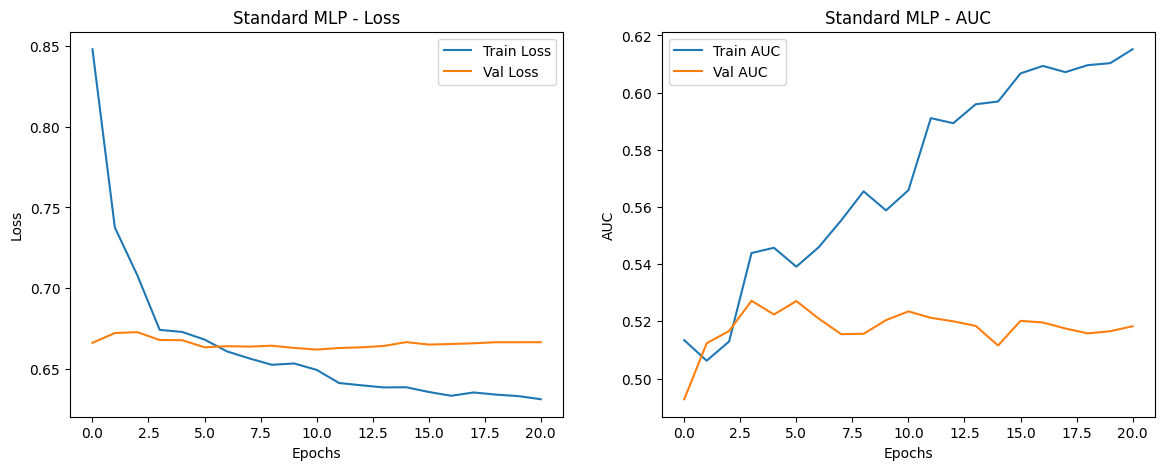

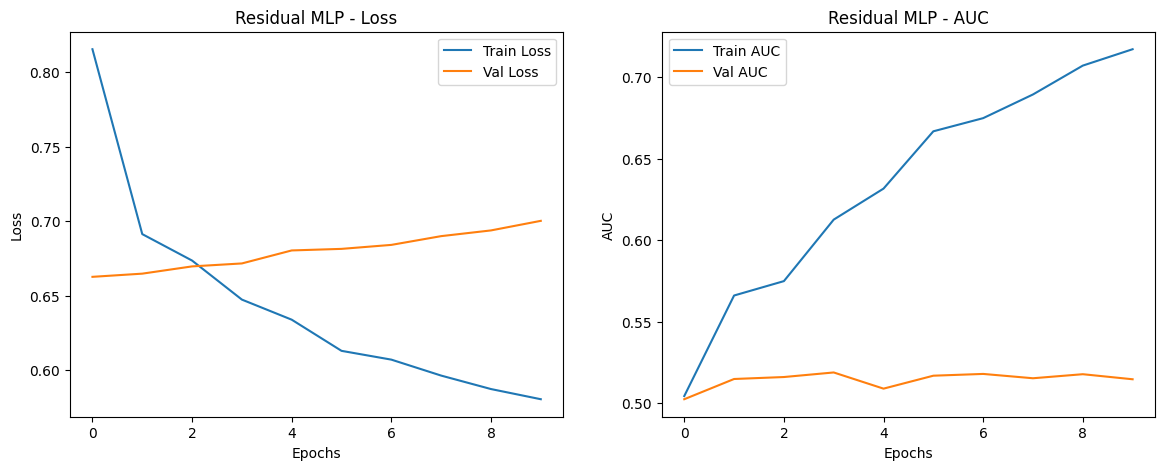

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

================ Standard MLP Evaluation Report ================
              precision    recall  f1-score   support

           0       0.64      0.99      0.78      1125
           1       0.25      0.00      0.01       628

    accuracy                           0.64      1753
   macro avg       0.45      0.50      0.39      1753
weighted avg       0.50      0.64      0.50      1753



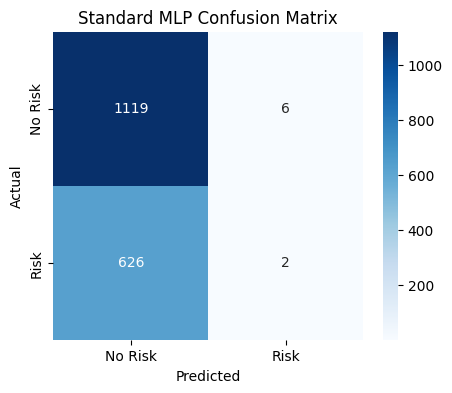

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

================ Residual MLP Evaluation Report ================
              precision    recall  f1-score   support

           0       0.64      0.99      0.78      1125
           1       0.35      0.01      0.02       628

    accuracy                           0.64      1753
   macro avg       0.50      0.50      0.40      1753
weighted avg       0.54      0.64      0.51      1753



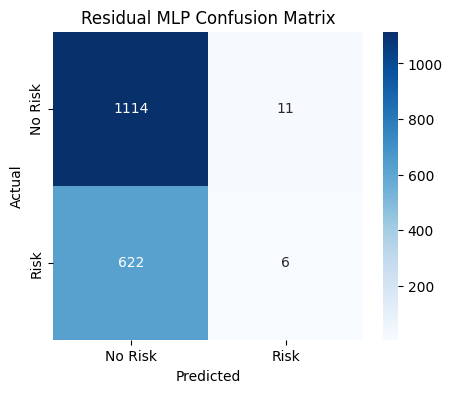

In [6]:
# ==========================================
# 6. Model Evaluation and Visualization
# ==========================================

# 6.1 Plot Training Loss and AUC Curves
def plot_history(history, model_name):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Loss Curve
    ax[0].plot(history.history['loss'], label='Train Loss')
    ax[0].plot(history.history['val_loss'], label='Val Loss')
    ax[0].set_title(f'{model_name} - Loss')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()

    # AUC Curve
    ax[1].plot(history.history['auc'], label='Train AUC')
    ax[1].plot(history.history['val_auc'], label='Val AUC')
    ax[1].set_title(f'{model_name} - AUC')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('AUC')
    ax[1].legend()

    plt.show()

plot_history(history_mlp, "Standard MLP")
plot_history(history_res, "Residual MLP")

# 6.2 Prediction and Classification Report
def evaluate_model(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    print(f"\n================ {model_name} Evaluation Report ================")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Risk', 'Risk'], yticklabels=['No Risk', 'Risk'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return y_pred_prob

y_pred_mlp = evaluate_model(mlp_model, X_test, y_test, "Standard MLP")
y_pred_res = evaluate_model(res_model, X_test, y_test, "Residual MLP")

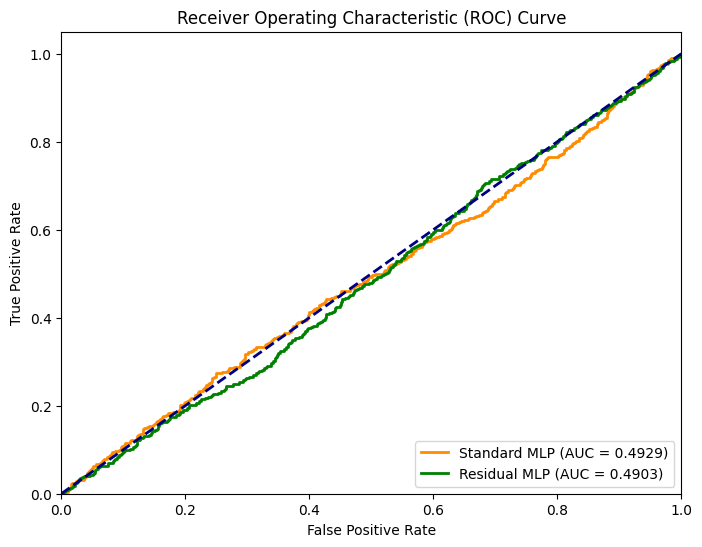

In [7]:
# ==========================================
# 7. ROC Curve Comparison
# ==========================================

fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_pred_mlp)
fpr_res, tpr_res, _ = roc_curve(y_test, y_pred_res)

auc_mlp = roc_auc_score(y_test, y_pred_mlp)
auc_res = roc_auc_score(y_test, y_pred_res)

plt.figure(figsize=(8, 6))
plt.plot(fpr_mlp, tpr_mlp, label=f'Standard MLP (AUC = {auc_mlp:.4f})', color='darkorange', lw=2)
plt.plot(fpr_res, tpr_res, label=f'Residual MLP (AUC = {auc_res:.4f})', color='green', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()